<a href="https://colab.research.google.com/github/stefanmello11/Colab-Files/blob/main/CS_Project_NFL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

NFL running backs play an important part of NFL teams offense as in 2025 43.07% of plays on offense were rushes. Because of this many fans assume that your rushing attack is essential to winning games. But is winning actually correlated to a strong and productive run game? This question becomes important when looking at modern NFL offenses, where teams spend the most money on elite quarterbacks to have a high powered passing attack, and seem to be least concerned about overpaying for elite running backs. So should teams be concerned in spending for a top tier rushing attack? Or should they allocate their money on an elite passing attack?

With that being said I think a team's rushing attack is not important to winning. As I think a strong passing offense is far more valuable to have success in the NFL. The passing game opens up the offense as a strong passing attack could cause a 40+ yards throw to go over a defense. When the defense respects the pass game, they can not stack defenders at the line of scrimmage, making running more difficult. Another huge part of winning games is needing to score at the last second to win in tight games or coming back from a slow start, and teams often lean towards the pass in those situations. Although having an elite running game can be nice to have, I do not think it is as impactful to winning compared to having a dynamic passing offense.



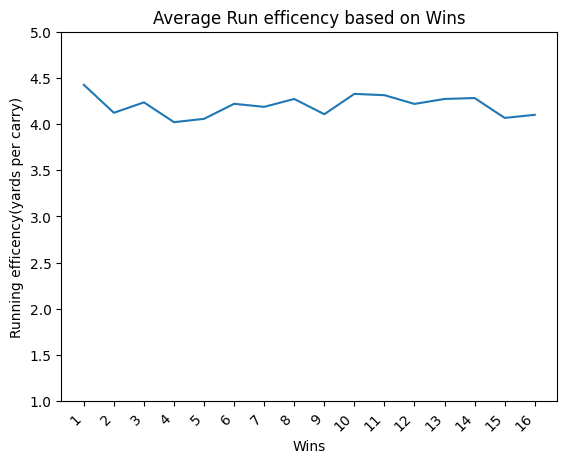

In [ ]:
import matplotlib.pyplot as plt
import csv

with open('team_stats_2003_2023.csv', 'r') as f:
  reader= csv.reader(f)
  # skips the header row which is the column title
  heading= next(reader)

  rows= []
  # stores each row in a list
  for row in reader:
    rows.append(row)
  # list of possible win totals and put into strings to match csv format(X axis)
  possible_win= ['1','2','3','4','5','6','7','8','9','10', '11', '12', '13','14'
  ,'15','16']

  wins= [] #this will store all the average rushing efficency for
   # each win total(Y axis)


  # loops through all possible wins
  for w in possible_win:
    total = 0 #  rushing efficency totals added up
    count= 0 #  number of teams with this win total

  # loops through all rows in data set
    for row in rows:
      if int(row[2]) == int(w):
        # check if the team's wins, matches current win value
        total += float(row[26]) # adds rushing effiency
        count+=1 # increase the count of teams with same number of wins

    if count != 0: #  avoids calculation error
      average = total / count#caculate average by running efficency/ total teams
    else:
      average= 0
      # stores calculated average in the list
    wins.append(average)


plt.plot(possible_win, wins,)
plt.ylim(1,5) # set y axis limits for better visualization
plt.title('Average Run efficency based on Wins')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.xlabel('Wins')
plt.ylabel('Running efficency(yards per carry)')
plt.show()


This graph shows that regardless of the number of wins, the running efficiency stays relatively the same. The yards per carry mostly stays between a range of 4.0-4.5, and as wins increase the run efficiency does not increase with it as the line is relatively flat. This pattern suggests that there is little to no correlation between a team's rushing efficiency and a team's total wins, so this graph helps prove my hypothesis that a team's rushing attack does not lead to winning.

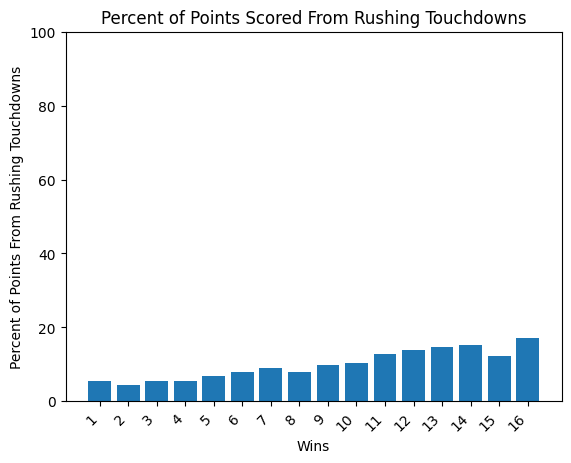

In [ ]:
import matplotlib.pyplot as plt
import csv

with open('team_stats_2003_2023.csv', 'r') as f:
  reader= csv.reader(f)
  heading= next(reader)

  rows= []
  for row in reader:
    rows.append(row)
possible_wins = ['1','2','3','4','5','6','7','8','9','10', '11', '12', '13','14'
  ,'15','16']

percent_points= [] #stores the average percent of points scored from run

# loops through each win total
for w in possible_wins:
  total_percent= 0 # add up the percentages for this win total
  count= 0 # number of teams that have this win total
  for row in rows:
    # check if team wins matches the win total I am looping through
    if int(row[2]) == int(w):
      total_points= float(row[14]) # gets total points scored by team
      rushing_touchdowns= float(row[-10]) # gets number of rushing touchdowns
      # calculate total points coming from rushing touchdowns
      percent= (rushing_touchdowns * 6) / total_points
      total_percent+=percent # add to total percentage
      count+=1 # count this team
  if count != 0: # avoid calculation errors
  #calculate the total average percentage between all teams with that win total
    average= total_percent / count
  else:
    average=0

  percent_points.append(average) # stores average for win total

plt.bar(possible_wins, percent_points)
plt.ylim(0,100)
plt.title('Percent of Points Scored From Rushing Touchdowns')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.xlabel('Wins')
plt.ylabel('Percent of Points From Rushing Touchdowns')
plt.show()






This graph continues to prove my hypothesis as it shows that a small percent of a team's points come from rushing the ball, no matter their amount of wins. This means that NFL teams constantly score way more points through the air and therefore that should mean it is a more important factor to a high-powered offense. This also implies that rushing plays seem to play a secondary role in NFL offenses, and continues to show that having a good rushing attack is not a significant factor to winning.

Enter first win total:9
Enter second win total:2


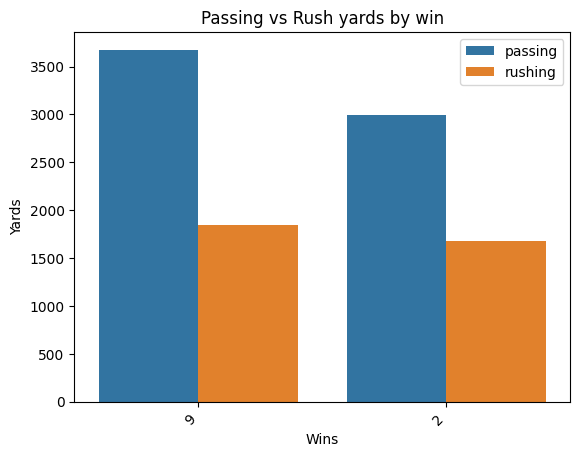

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import csv

with open('team_stats_2003_2023.csv', 'r') as f:
  reader= csv.reader(f)
  heading= next(reader)

  rows= []
  for row in reader:
    rows.append(row)
# ask user to input to diffrent win totals so that I can compare them
win_1 = input("Enter first win total:")
win_2 = input("Enter second win total:")
# function to calculate the average rushing and passing yards for each win total
def get_averages(win_total):
  total_pass = 0 # sum of pass yards
  total_rush= 0 # total of rush yards
  count = 0 # total amount of teams with this win total

  for row in rows:
    if int(row[2]) == int(win_total):
      #checks if teams win matches current win total
      total_pass += float(row[18]) # adds passing yards
      total_rush += float(row[24]) # adds rushing yards
      count+=1 # adds to team total
  if count != 0:
    #calculate averages for rush and pass, and alsoavoids divison by zero errors
    avg_pass= total_pass / count
    avg_rush= total_rush/count
  else:
    avg_pass=0
    avg_rush=0
  return avg_pass, avg_rush # return both averages
# get averages for both user chosen win totals
pass1, rush1 = get_averages(win_1)
pass2, rush2 = get_averages(win_2)

# prepare data for seaborn bar graph
# each win total appears twice (rushing, passing)
#and seaborn can seperate them using "hue"
win_lable = [win_1,win_1,win_2,win_2]
types= ["passing", "rushing", "passing", "rushing"]
yards= [pass1, rush1, pass2, rush2]
# creates a bar chart comparing pass yards and rushing yards
#seaborn automaticlly colors the bars and then it creates a legend
sns.barplot(x=win_lable, y=yards, hue=types)
plt.title('Passing vs Rush yards by win')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.xlabel('Wins')
plt.ylabel('Yards')
plt.show()


 In this graph the user got to input 2 different win amounts and the bar graph would tell them the average passing and rushing yards total. A pattern that I noticed is when I compared a win total that is low versus a win total that is high, the total passing yard average was always higher for the better win total. As a result the rushing stats would also be higher which shows that when a team has a better passing attack, it leads to a better running attack. This helps answer my question about if running matters to winning, and again this graph makes the passing game look more important as a team always has more passing yards than rushing, and the run game stems off a successful pass game.

While attempting to seek out an answer to if having a good rushing attack leads to victories, I think now I have an answer to that question. All three graphs seemed to prove my hypothesis correct, as all of them made a team's running game seem like a non factor to winning. In these graphs I noticed a pattern that the teams with low win totals had similar rushing statistics to teams with higher win totals. This shows a better rushing attack does not guarantee wins. These data visualizations are important because many NFL fans are still under the impression that you need a good rushing attack to find success in the NFL and build a high-powered offense. Some NFL fans even want their teams to waste high draft picks to draft or trade elite running backs, but I hope these graphs show them that there are more important positions to worry about than running back.

My CSV was very helpful for finding a solution for my hypothesis, but my data was only from 2003 to 2023. This can be viewed as a limitation, but as NFl  offensive approaches constantly change between decades, I think it is important to look at the data for the most modern offenses. So with that being said, maybe in the 80's an effective rushing attack could lead to winning, but what we can take away from these visualizations is that in the modern NFL teams do not need an effective offense to win games. If I were to add another data visualization, I would make a graph that shows how many rushing attempts a team has compared to their win total. This would help me understand if the teams with higher win totals ran the ball more than teams with low win totals or if it was all relatively the same.